### panc analysis (batch effect correction)

In [1]:
import os
os.chdir('/data2/zhouwg_data/project/Garfield')
os.getcwd()

'/data2/zhouwg_data/project/Garfield'

In [2]:
# load packages
import os
import warnings
import Garfield as gf
import scanpy as sc
from mudata import MuData
warnings.simplefilter(action="ignore", category=FutureWarning)

gf.__version__

'0.1.2'

In [3]:
## 读取数据
# adata = sc.read_loom('../Garfield_test/data/panc8.loom',sparse=False)  #Load cell line dataset(-> count data). 
adata = sc.read_h5ad('../Garfield_test/data/panc8.h5ad')
# celltype = adata.obs['celltype']
adata

AnnData object with n_obs × n_vars = 14890 × 34363
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA'
    var: 'Selected', 'vst_mean', 'vst_variable', 'vst_variance', 'vst_variance_expected', 'vst_variance_standardized'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings'
    varm: 'pca_feature_loadings'
    layers: 'counts', 'norm_data', 'scale_data'

In [4]:
adata.layers['counts'] = adata.X.copy()

In [5]:
adata.obs['batch'].value_counts()

batch
indrop        8569
smartseq2     2394
celseq2       2285
celseq        1004
fluidigmc1     638
Name: count, dtype: int64

In [6]:
# set workdir
workdir = 'result_garfield_scRNA_panc' # result_garfield_multiome_10xpbmc3k_10k_Unpaired
gf.settings.set_workdir(workdir)

Saving results in: result_garfield_scRNA_panc


In [7]:
gf.settings.set_figure_params(dpi=80,
                              style='white',
                              fig_size=[5,5],
                              rc={'image.cmap': 'viridis'})

In [8]:
# make plots prettier
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

In [9]:
### modify parameter
user_config = dict(
    ## Input options
    data_dir=workdir,  # STR     Location of the dataset to be used.         Default is `data`.
    project_name='scRNA_adata_panc',  # STR     Name of the dataset to be used.             Default is `name`.
    adata_list=adata,  # STR     adata object of single-cell dataset.         Default is `adata`.
    profile='RNA',
    data_type=None,  # Paired
    genome='hg38',
    sample_col='batch',  # STR     Column name of sample in adata.obs.       Default is `batch`.

    ## Preprocessing options
    rna_n_top_features=3000,
    atac_n_top_features=10000,  # INT     Number of top genes to be selected.       Default is 2000.
    metric='euclidean',  # STR     Metric for clustering.                   Default is `correlation`. euclidean

    ## Model options
    gnn_layer=2,
    hidden_dims=[128, 128],
    svd_q=5,  # default=5, type=int, help='rank'
    cluster_num=20,
    used_edge_weight=True,
    used_recon_exp=True,
    used_DSBN=True,
    used_mmd=True,
    batch_size=128,  # INT   batch size of model training
    num_neighbors=[5, 5],
    epochs=50,  # INT       Number of epochs.                        Default is 100.
    mmd_temperature=0.2,  ## mmd regu
    instance_temperature=1.0,
    cluster_temperature=0.5,
    monitor_only_val_losses=False,
    learning_rate=0.001
)
dict_config = gf.settings.set_gf_params(user_config)

In [10]:
## start training
from Garfield.model import GarfieldTrainer
trainer = GarfieldTrainer(dict_config)
trainer.fit()


Preparing dataset...

Data files exist, loading...
Finished loading.

Model training.

 |███-----------------| 16.0%  - epoch_total_loss: 1579.8507080078 - epoch_vgae_loss: 0.1471093334 - epoch_instance_loss: 7.3576405048 - epoch_cluster_loss: 2.2142049074 - epoch_recon_loss: 1560.4743041992 - epoch_regu_loss: 8.0722618103 - epoch_mmd_loss: 7.9262490273 - val_total_loss: 1520.9006347656 - val_vgae_loss: 0.1964676529 - val_instance_loss: 6.8147878647 - val_cluster_loss: 2.2369670868 - val_recon_loss: 1501.0136718750 - val_regu_loss: 8.0732526779 - val_mmd_loss: 12.8279485703 - test_roc_auc: 0.5000000000 - test_precision: 0.500000000003

EarlyStopping: run 8 epoch
Model is saved under result_garfield_scRNA_panc/checkpoint/model.pt.


In [11]:
import scanpy as sc
adata_final = trainer.get_latent_representation()
adata_final

eval mode
Perform get_latent for cells via mini-batch mode


AnnData object with n_obs × n_vars = 14890 × 3000
    obs: 'ClusterID', 'ClusterName', 'batch', 'celltype', 'nCount_RNA', 'n_genes'
    var: 'Selected', 'vst_mean', 'vst_variable', 'vst_variance', 'vst_variance_expected', 'vst_variance_standardized', 'n_cells', 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'pca_cell_embeddings', 'umap_cell_embeddings', 'X_pca', 'X_gf'
    varm: 'pca_feature_loadings', 'PCs'
    layers: 'counts', 'norm_data', 'scale_data'
    obsp: 'distances', 'connectivities'

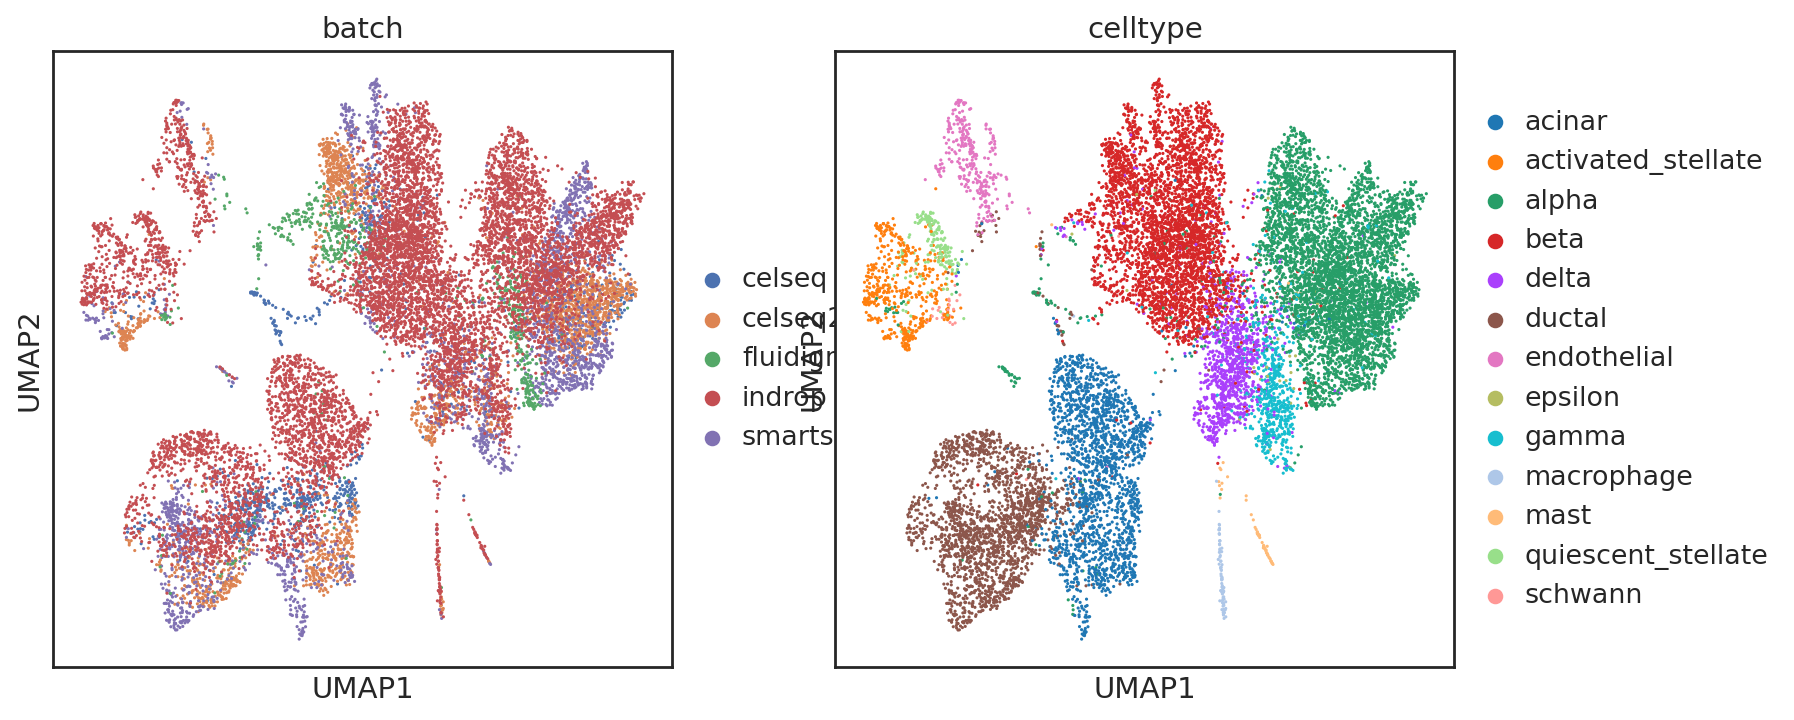

In [12]:
sc.tl.umap(adata_final)

# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['batch', 'celltype'], wspace=0.15, edges=False)

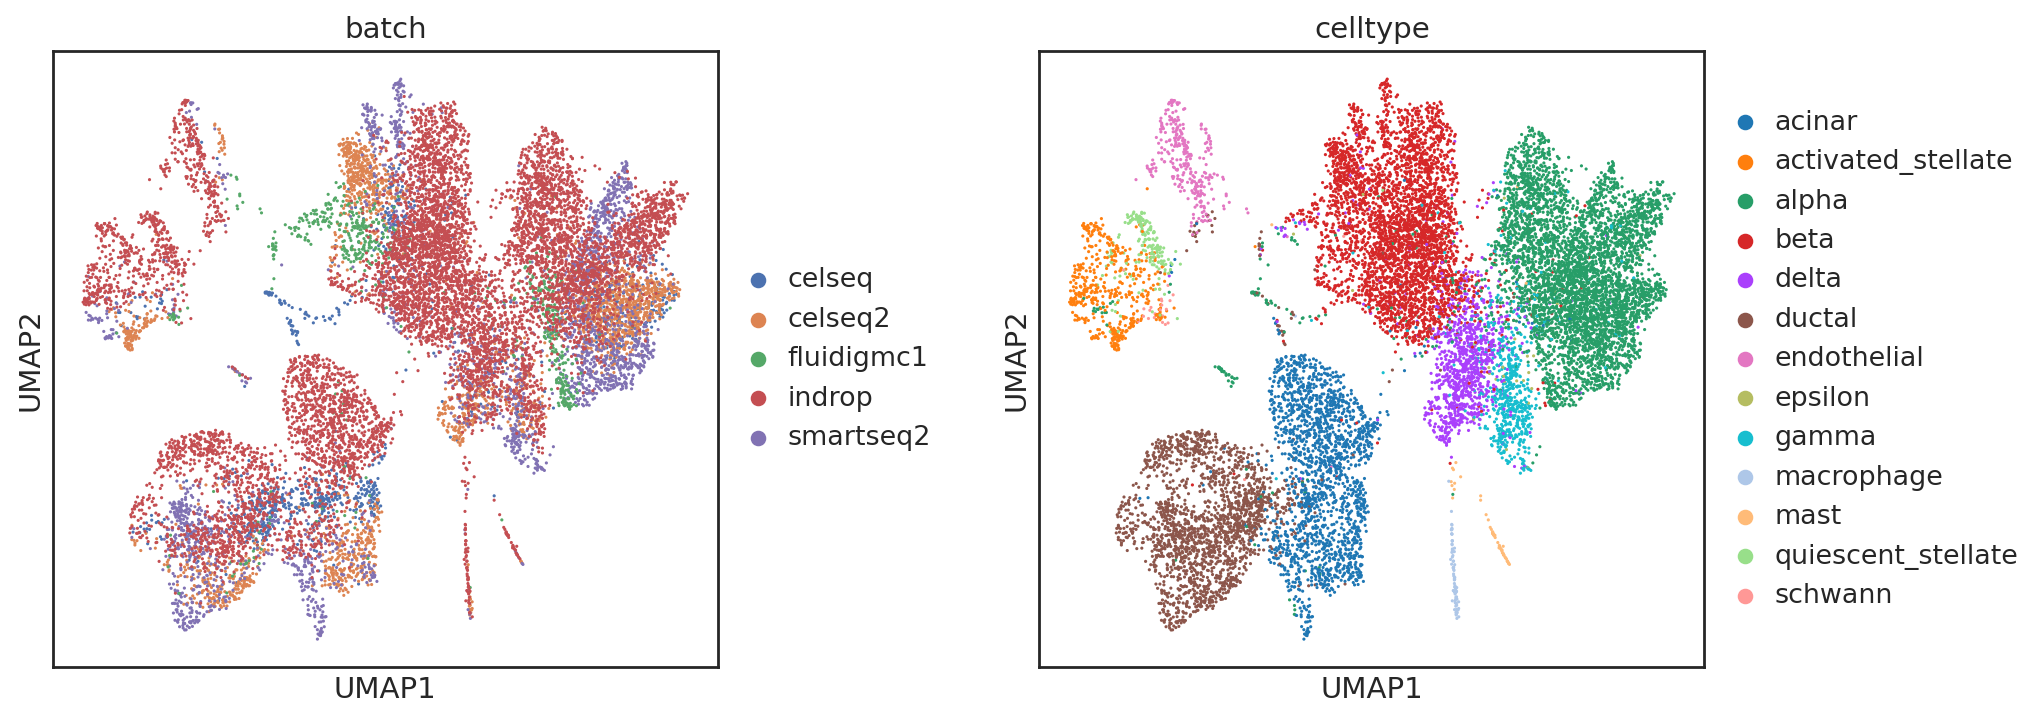

In [13]:
#设置全域sc的画图背景为白色，dpi=50分辨率
# sc.settings.set_figure_params(dpi=80, facecolor="black")

sc.pl.umap(adata_final, color=['batch', 'celltype'], wspace=0.35, edges=False, save='_panc_umap.pdf')

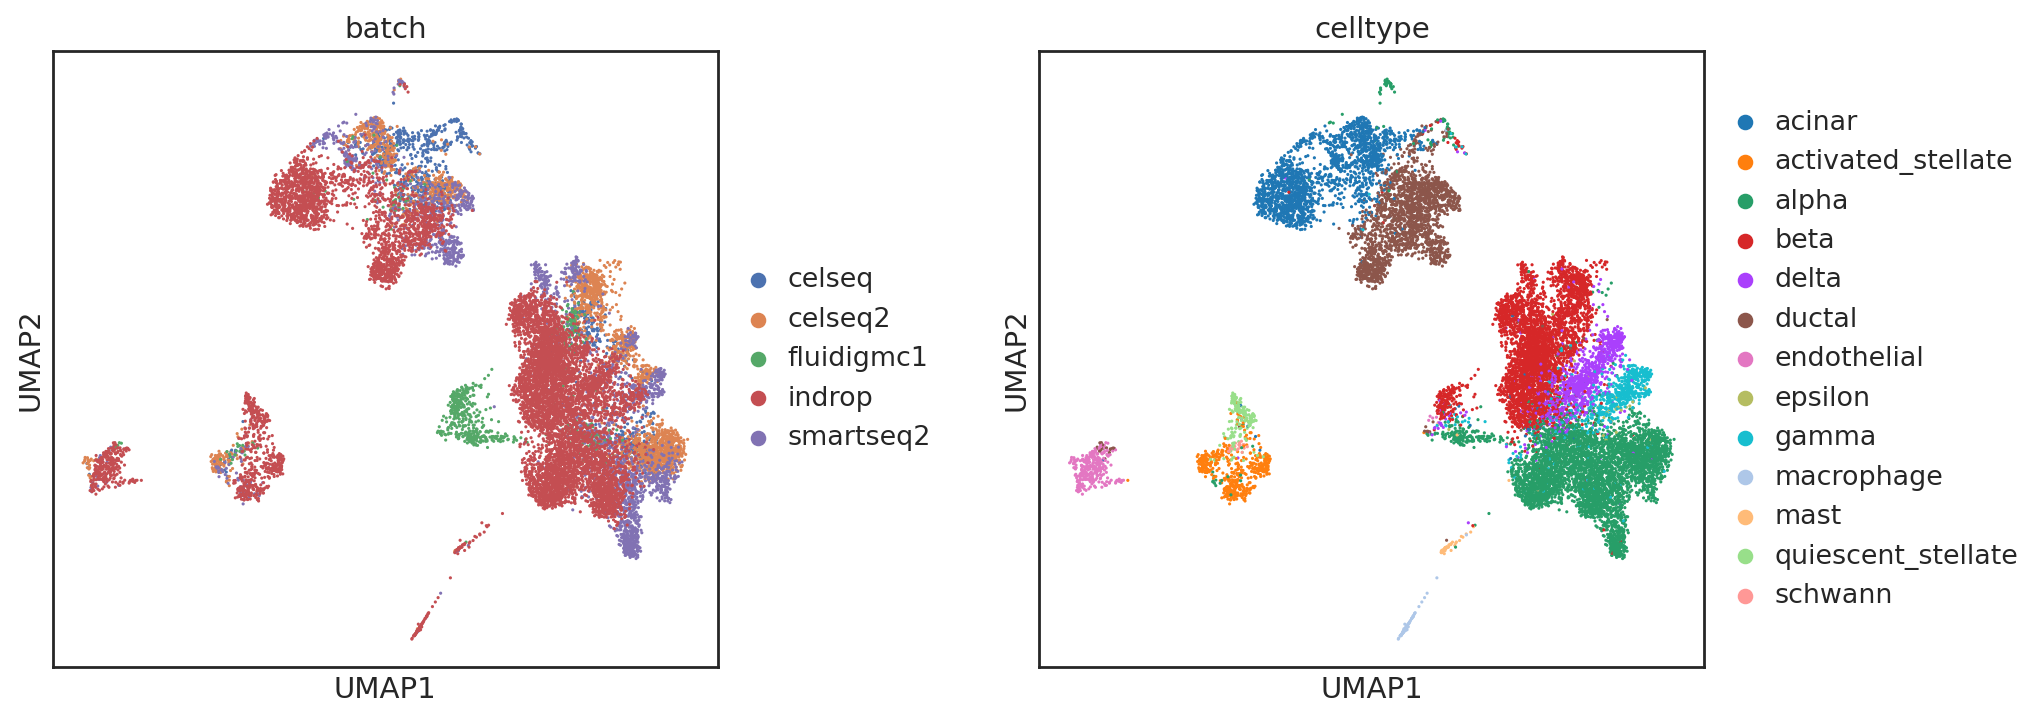

In [15]:
### scanorama 对照
sc.pp.neighbors(adata_final, use_rep='X_scanorama')
sc.tl.umap(adata_final)

# adata_final.obs['celltype'] = adata_final.obs['celltype'].astype('category')
sc.pl.umap(adata_final, color=['batch', 'celltype'], wspace=0.35, edges=False, save='_panc_umap_scanorama.pdf')